In [1]:
import matplotlib.pyplot as plt

# Exemple : Séquence d'une partie du gène de l'insuline humaine
dna_sequence = "AGCCCTCCAGGACAGGCTGCATCAGAAGAGGCCATCAAGCAGGTCTGTTCCAAGGGCCTTTGCGTCAGGTGGGCTCAGGATTCCAGGGTGGCTGGACCCAGG"
print(f"Séquence chargée : {len(dna_sequence)} bases")


Séquence chargée : 102 bases


In [2]:
#Fonctions d'analyse
def analyze_sequence(seq):
    seq = seq.upper()
    stats = {base: seq.count(base) for base in "ATCG"}
    
    # Calcul du taux de GC (G+C / Total)
    gc_content = (stats['G'] + stats['C']) / len(seq) * 100
    
    return stats, gc_content

stats, gc = analyze_sequence(dna_sequence)
print(f"Taux de GC : {gc:.2f}%")

Taux de GC : 61.76%


In [3]:
#Traduction en Protéines
def translate(dna):
    table = {
        'ATA':'I', 'ATC':'I', 'ATT':'I', 'ATG':'M', 'ACA':'T', 'ACC':'T', 'ACG':'T', 'ACT':'T',
        'AAC':'N', 'AAT':'N', 'AAA':'K', 'AAG':'K', 'AGC':'S', 'AGT':'S', 'AGA':'R', 'AGG':'R',
        'CTA':'L', 'CTC':'L', 'CTG':'L', 'CTT':'L', 'CCA':'P', 'CCC':'P', 'CCG':'P', 'CCT':'P',
        'CAC':'H', 'CAT':'H', 'CAA':'Q', 'CAG':'Q', 'CGA':'R', 'CGC':'R', 'CGG':'R', 'CGT':'R',
        'GTA':'V', 'GTC':'V', 'GTG':'V', 'GTT':'V', 'GCA':'A', 'GCC':'A', 'GCG':'A', 'GCT':'A',
        'GAC':'D', 'GAT':'D', 'GAA':'E', 'GAG':'E', 'GGA':'G', 'GGC':'G', 'GGG':'G', 'GGT':'G',
        'TCA':'S', 'TCC':'S', 'TCG':'S', 'TCT':'S', 'TTC':'F', 'TTT':'F', 'TTA':'L', 'TTG':'L',
        'TAC':'Y', 'TAT':'Y', 'TAA':'_', 'TAG':'_', 'TGC':'C', 'TGT':'C', 'TGA':'_', 'TGG':'W',
    }
    protein = ""
    for i in range(0, len(dna) - (len(dna) % 3), 3):
        codon = dna[i:i+3]
        protein += table.get(codon, '?')
    return protein

print(f"Séquence protéique : {translate(dna_sequence)}")


Séquence protéique : SPPGQAASEEAIKQVCSKGLCVRWAQDSRVAGPR


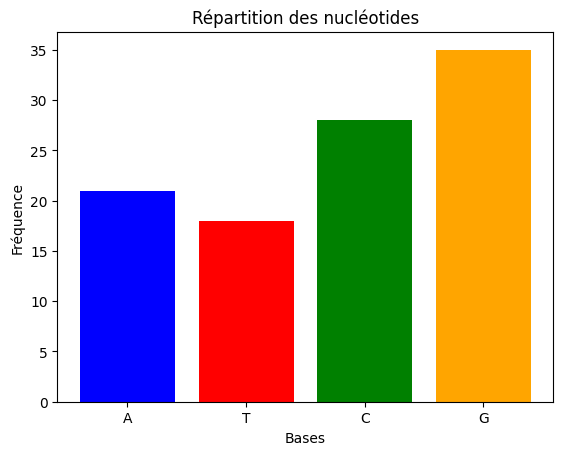

In [4]:
#Visualisation
plt.bar(stats.keys(), stats.values(), color=['blue', 'red', 'green', 'orange'])
plt.title("Répartition des nucléotides")
plt.xlabel("Bases")
plt.ylabel("Fréquence")
plt.show()


Séquence chargée : 102 bases
Taux de GC : 61.76%
Séquence protéique : SPPGQAASEEAIKQVCSKGLCVRWAQDSRVAGPR

Encodage HP (34 résidus) : PHHHPHHPPPHHHPHHPHHHHHPHHPPPPHHHHP

─── Q-Learning en cours ───
  Épisode  500/3000 | ε=0.0816 | meilleure énergie=-9
  Épisode 1000/3000 | ε=0.0067 | meilleure énergie=-9
  Épisode 1500/3000 | ε=0.0005 | meilleure énergie=-9
  Épisode 2000/3000 | ε=0.0000 | meilleure énergie=-9
  Épisode 2500/3000 | ε=0.0000 | meilleure énergie=-9
  Épisode 3000/3000 | ε=0.0000 | meilleure énergie=-9

✓ Résultat : énergie optimale = -9 contacts H-H
  Directions : →↑←↑↑←↓←↑↑←↑↑→→→↓←↓→→→→→→↓↓←↑←←←↓


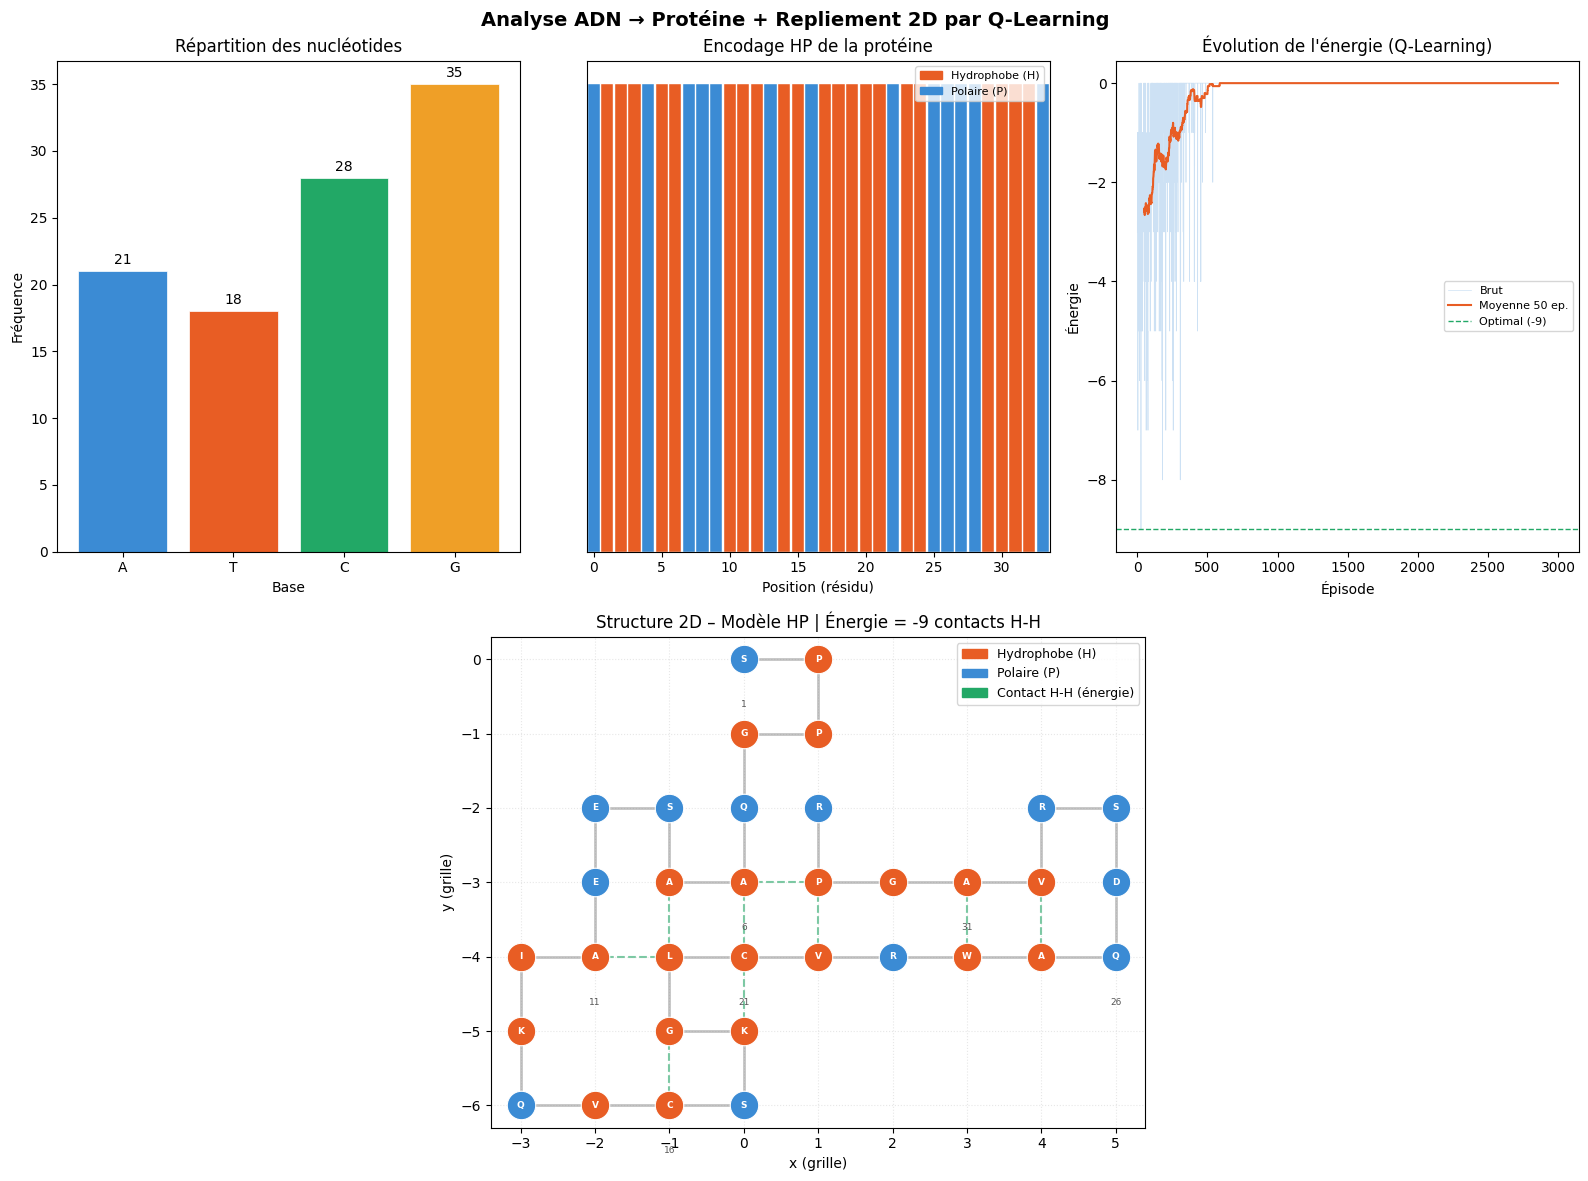


Figure sauvegardée : protein_qlearning_2d.png


In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import random
from collections import defaultdict

# ─────────────────────────────────────────────
# 1. SÉQUENCE ADN & ANALYSE
# ─────────────────────────────────────────────
dna_sequence = "AGCCCTCCAGGACAGGCTGCATCAGAAGAGGCCATCAAGCAGGTCTGTTCCAAGGGCCTTTGCGTCAGGTGGGCTCAGGATTCCAGGGTGGCTGGACCCAGG"
print(f"Séquence chargée : {len(dna_sequence)} bases")


def analyze_sequence(seq):
    seq = seq.upper()
    stats = {base: seq.count(base) for base in "ATCG"}
    gc_content = (stats['G'] + stats['C']) / len(seq) * 100
    return stats, gc_content


stats, gc = analyze_sequence(dna_sequence)
print(f"Taux de GC : {gc:.2f}%")

# ─────────────────────────────────────────────
# 2. TRADUCTION EN PROTÉINE
# ─────────────────────────────────────────────
def translate(dna):
    table = {
        'ATA':'I','ATC':'I','ATT':'I','ATG':'M','ACA':'T','ACC':'T','ACG':'T','ACT':'T',
        'AAC':'N','AAT':'N','AAA':'K','AAG':'K','AGC':'S','AGT':'S','AGA':'R','AGG':'R',
        'CTA':'L','CTC':'L','CTG':'L','CTT':'L','CCA':'P','CCC':'P','CCG':'P','CCT':'P',
        'CAC':'H','CAT':'H','CAA':'Q','CAG':'Q','CGA':'R','CGC':'R','CGG':'R','CGT':'R',
        'GTA':'V','GTC':'V','GTG':'V','GTT':'V','GCA':'A','GCC':'A','GCG':'A','GCT':'A',
        'GAC':'D','GAT':'D','GAA':'E','GAG':'E','GGA':'G','GGC':'G','GGG':'G','GGT':'G',
        'TCA':'S','TCC':'S','TCG':'S','TCT':'S','TTC':'F','TTT':'F','TTA':'L','TTG':'L',
        'TAC':'Y','TAT':'Y','TAA':'_','TAG':'_','TGC':'C','TGT':'C','TGA':'_','TGG':'W',
    }
    protein = ""
    for i in range(0, len(dna) - (len(dna) % 3), 3):
        codon = dna[i:i+3]
        protein += table.get(codon, '?')
    return protein


protein_seq = translate(dna_sequence)
print(f"Séquence protéique : {protein_seq}")

# ─────────────────────────────────────────────
# 3. ENCODAGE HP (Hydrophobe / Polaire)
# ─────────────────────────────────────────────
HP_MAP = {
    'A':'H','C':'H','F':'H','G':'H','H':'H','I':'H',
    'K':'H','L':'H','M':'H','P':'H','V':'H','W':'H','Y':'H',
    'D':'P','E':'P','N':'P','Q':'P','R':'P','S':'P','T':'P'
}

hp_seq = [HP_MAP.get(aa, 'P') for aa in protein_seq]
N = len(hp_seq)
print(f"\nEncodage HP ({N} résidus) : {''.join(hp_seq)}")

# ─────────────────────────────────────────────
# 4. ENVIRONNEMENT DE REPLIEMENT 2D
# ─────────────────────────────────────────────
# Directions : 0=Droite, 1=Haut, 2=Gauche, 3=Bas
DIRECTIONS = [(1, 0), (0, -1), (-1, 0), (0, 1)]
DIR_NAMES  = ['→', '↑', '←', '↓']


def simulate(actions):
    """Retourne la liste de positions (x,y) ou None si collision."""
    pos = [(0, 0)]
    visited = {(0, 0)}
    for a in actions:
        dx, dy = DIRECTIONS[a]
        nx, ny = pos[-1][0] + dx, pos[-1][1] + dy
        if (nx, ny) in visited:
            return None
        visited.add((nx, ny))
        pos.append((nx, ny))
    return pos


def compute_energy(pos):
    """Énergie = -nombre de contacts H-H non consécutifs adjacents."""
    energy = 0
    for i in range(len(pos)):
        if hp_seq[i] != 'H':
            continue
        for j in range(i + 2, len(pos)):
            if hp_seq[j] != 'H':
                continue
            if abs(pos[i][0] - pos[j][0]) + abs(pos[i][1] - pos[j][1]) == 1:
                energy -= 1
    return energy

# ─────────────────────────────────────────────
# 5. Q-LEARNING
# ─────────────────────────────────────────────
EPISODES   = 3000
ALPHA      = 0.5      # taux d'apprentissage
GAMMA      = 0.9      # facteur d'actualisation
EPSILON    = 1.0      # exploration initiale
DECAY      = 0.9950   # décroissance ε par épisode

Q = defaultdict(lambda: defaultdict(float))

best_energy = float('inf')
best_pos    = None
best_actions= None
energy_history = []

print("\n─── Q-Learning en cours ───")
for episode in range(1, EPISODES + 1):
    actions = []
    pos     = [(0, 0)]
    visited = {(0, 0)}
    dead    = False

    for step in range(N - 1):
        state = tuple(actions)

        # Actions valides (sans collision)
        valid = []
        for a in range(4):
            dx, dy = DIRECTIONS[a]
            nx, ny = pos[-1][0] + dx, pos[-1][1] + dy
            if (nx, ny) not in visited:
                valid.append(a)

        if not valid:
            dead = True
            break

        # Politique ε-greedy
        if random.random() < EPSILON:
            action = random.choice(valid)
        else:
            action = max(valid, key=lambda a: Q[state][a])

        dx, dy = DIRECTIONS[action]
        nx, ny = pos[-1][0] + dx, pos[-1][1] + dy
        visited.add((nx, ny))
        pos.append((nx, ny))
        actions.append(action)

        next_state = tuple(actions)
        energy     = compute_energy(pos)
        reward     = -energy if step == N - 2 else 0

        # Mise à jour Q
        max_next = max(Q[next_state].values(), default=0.0)
        Q[state][action] += ALPHA * (reward + GAMMA * max_next - Q[state][action])

    if not dead:
        e = compute_energy(pos)
        energy_history.append(e)
        if e < best_energy:
            best_energy  = e
            best_pos     = pos[:]
            best_actions = actions[:]
    else:
        energy_history.append(0)

    EPSILON *= DECAY

    if episode % 500 == 0:
        print(f"  Épisode {episode:4d}/{EPISODES} | ε={EPSILON:.4f} | meilleure énergie={best_energy}")

print(f"\n✓ Résultat : énergie optimale = {best_energy} contacts H-H")
print(f"  Directions : {''.join(DIR_NAMES[a] for a in best_actions)}")

# ─────────────────────────────────────────────
# 6. VISUALISATIONS
# ─────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
fig.suptitle("Analyse ADN → Protéine + Repliement 2D par Q-Learning", fontsize=14, fontweight='bold')

# ── 6a. Répartition des nucléotides ──────────
ax1 = fig.add_subplot(2, 3, 1)
colors_nuc = ['#3B8BD4', '#E85D24', '#22a866', '#EF9F27']
ax1.bar(stats.keys(), stats.values(), color=colors_nuc, edgecolor='white', linewidth=0.5)
ax1.set_title("Répartition des nucléotides")
ax1.set_xlabel("Base")
ax1.set_ylabel("Fréquence")
for bar, val in zip(ax1.patches, stats.values()):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(val), ha='center', va='bottom', fontsize=10)

# ── 6b. Encodage HP ──────────────────────────
ax2 = fig.add_subplot(2, 3, 2)
hp_colors = ['#E85D24' if h == 'H' else '#3B8BD4' for h in hp_seq]
ax2.bar(range(N), [1]*N, color=hp_colors, width=0.9, edgecolor='white', linewidth=0.3)
ax2.set_title("Encodage HP de la protéine")
ax2.set_xlabel("Position (résidu)")
ax2.set_yticks([])
ax2.set_xlim(-0.5, N - 0.5)
h_patch = mpatches.Patch(color='#E85D24', label='Hydrophobe (H)')
p_patch = mpatches.Patch(color='#3B8BD4', label='Polaire (P)')
ax2.legend(handles=[h_patch, p_patch], fontsize=8, loc='upper right')

# ── 6c. Courbe d'énergie ─────────────────────
ax3 = fig.add_subplot(2, 3, 3)
window = 50
smoothed = np.convolve(energy_history, np.ones(window)/window, mode='valid')
ax3.plot(energy_history, alpha=0.25, color='#3B8BD4', linewidth=0.5, label='Brut')
ax3.plot(range(window-1, len(energy_history)), smoothed, color='#E85D24', linewidth=1.5, label=f'Moyenne {window} ep.')
ax3.set_title("Évolution de l'énergie (Q-Learning)")
ax3.set_xlabel("Épisode")
ax3.set_ylabel("Énergie")
ax3.legend(fontsize=8)
ax3.axhline(best_energy, color='#22a866', linestyle='--', linewidth=1, label=f'Optimal ({best_energy})')
ax3.legend(fontsize=8)

# ── 6d. Structure 2D de la protéine ──────────
ax4 = fig.add_subplot(2, 1, 2)
ax4.set_aspect('equal')
ax4.set_title(f"Structure 2D – Modèle HP | Énergie = {best_energy} contacts H-H", fontsize=12)

if best_pos:
    xs = [p[0] for p in best_pos]
    ys = [p[1] for p in best_pos]

    # Contacts H-H (liaisons non covalentes)
    for i in range(N):
        if hp_seq[i] != 'H':
            continue
        for j in range(i + 2, N):
            if hp_seq[j] != 'H':
                continue
            if abs(best_pos[i][0]-best_pos[j][0]) + abs(best_pos[i][1]-best_pos[j][1]) == 1:
                ax4.plot([best_pos[i][0], best_pos[j][0]],
                         [best_pos[i][1], best_pos[j][1]],
                         color='#22a866', linewidth=1.5, linestyle='--', alpha=0.6, zorder=1)

    # Chaîne principale
    ax4.plot(xs, ys, color='#888', linewidth=2, zorder=2, alpha=0.5)

    # Nœuds
    for i, (x, y) in enumerate(best_pos):
        color = '#E85D24' if hp_seq[i] == 'H' else '#3B8BD4'
        ax4.scatter(x, y, s=420, c=color, zorder=3, edgecolors='white', linewidths=0.8)
        ax4.text(x, y, protein_seq[i], ha='center', va='center',
                 fontsize=6.5, fontweight='bold', color='white', zorder=4)

    # Numéros (tous les 5)
    for i in range(0, N, 5):
        ax4.text(best_pos[i][0], best_pos[i][1] - 0.55, str(i+1),
                 ha='center', va='top', fontsize=6.5, color='#555')

    # Légende
    h_p = mpatches.Patch(color='#E85D24', label='Hydrophobe (H)')
    p_p = mpatches.Patch(color='#3B8BD4', label='Polaire (P)')
    c_p = mpatches.Patch(color='#22a866', label='Contact H-H (énergie)')
    ax4.legend(handles=[h_p, p_p, c_p], loc='upper right', fontsize=9)
    ax4.set_xlabel("x (grille)")
    ax4.set_ylabel("y (grille)")
    ax4.grid(True, linestyle=':', alpha=0.3)
else:
    ax4.text(0.5, 0.5, "Aucune structure valide trouvée.\nAugmentez le nombre d'épisodes.",
             ha='center', va='center', transform=ax4.transAxes, fontsize=12)

plt.tight_layout()
plt.savefig("protein_qlearning_2d.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nFigure sauvegardée : protein_qlearning_2d.png")